# Joint Fit: Photometry + Lines

Notebook [`06`](06_fitting_spectroscopy.ipynb) fits an optical *spectrum* and
[`07`](07_joint_photo_spec.ipynb) fits photometry *and* a spectrum together. This
one fits the other kind of joint dataset that dominates modern surveys: a
**broadband photometry + emission-line-flux catalog**, of the kind
[FastSpecFit](https://fastspecfit.readthedocs.io) produces for DESI (and
MPA-JHU / RCSED for SDSS). Instead of a pixel-by-pixel spectrum we fit a
handful of measured line fluxes alongside the broadband points.

**Which model quantity matches a catalog line flux?** FastSpecFit fits a
stellar-continuum model (SPS templates, which carry the Balmer *absorption*),
subtracts it, and fits each line as a Gaussian on the residual — with the
[N II]/Hα and doublet kinematics tied so the blends deblend. What it reports
(`LINE_FLUX`) is therefore **pure, deblended, absorption-corrected emission**.
That is exactly what `model.predict_line_fluxes` returns — the backend's
emitted line luminosity, projected to a flux. It is *not* what a naive
bandpass measurement gives, which is why we fit `predict_line_fluxes` here and
not a window-integrated `measure_line_fluxes` (the latter would carry the
stellar absorption and mis-deblend [N II], biasing the Balmer decrement).

**What the two build-time opt-ins do.** They do *not* split one per data
channel. `WavePrecomp` is the photometry lookup — the SSP × filter table that
replaces a full SSP × wavelength integration with a table look-up.
`FeaturePrecomp` is the **nebular** lookup: a per-Q_H grid that keeps the Cue
emulator off the per-gradient path. The lines do ride it, but what it caches is
the *gas* calculation, which is why the name misleads.

**And on this fit neither one buys you much** — we measure that below rather
than claim otherwise. An observation carrying a line channel already keeps the
nebular work off the per-gradient path, so the exact forward is *already* fast
here and the opt-ins have little left to remove. Where `FeaturePrecomp` earns
its keep is the case that looks like it should not need it: the **same model
fit to photometry alone**, where every likelihood evaluation re-runs Cue and
the grid is worth an order of magnitude. "I am not fitting lines" is the
opposite of a reason to skip it — the `FeaturePrecomp` docstring carries that
measurement, as does `docs/dev/api_migration_v0.x.md`.

The catalog-scale argument is separate and survives either way: the look-up is
shared work across galaxies, so it is amortized once and reused — see
[notebook 11](11_catalog_fits.ipynb) for `fit_batch` at catalog scale.

In [1]:
from _setup import FIG_DIR, effective_wavelengths_um, quiet

quiet()

# Notebook-specific: the dense-mass NUTS run below deliberately uses
# dense_mass_matrix=True for convergence; its RAM caveat is discussed in the
# summary, not repeated here.
import warnings

warnings.filterwarnings("ignore", message=".*dense_mass_matrix.*")

import time
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import tengri
from tengri import (
    FIXED,
    FREE,
    FeaturePrecomp,
    Fixed,
    ForwardModel,
    LineList,
    Observation,
    Photometry,
    SEDModel,
    Uniform,
    WavePrecomp,
    cosmology,
    plot,
)
from tengri.observation import LineFluxData
from tengri.utils.conversions import lnu_to_fnu

plot.setup_style()

C_POST, C_TRUTH, C_DATA, C_LINE = "#3a76d9", "0.15", "#c3372a", "#2e8b57"

## Observation: DESI photometry + FastSpecFit strong lines

The DESI Legacy Imaging bands (DECam *grz* + WISE W1–W4) plus the strong
optical lines a FastSpecFit spectrum delivers: the [O II] doublet, the Balmer
lines, [O III], [N II], and [S II]. The line wavelengths come straight from
the built-in `LineList`; the observed fluxes and their errors go into a
`LineFluxData`, which the `Observation` carries alongside the photometry.
`model.fit` then fits both channels through one likelihood — no extra wiring.

In [2]:
SSP_NAME = "fsps_prsc_miles_chabrier"  # bare-stellar SSP (Cue adds the nebular emission)
ssp = tengri.load_ssp(SSP_NAME, download=True)

Z_GAL = 0.1
FILTERS = ["des_g", "des_r", "des_z", "wise_w1", "wise_w2", "wise_w3", "wise_w4"]
LINE_NAMES = [
    "OII_3726",
    "OII_3729",
    "Hbeta",
    "OIII_4959",
    "OIII_5007",
    "NII_6548",
    "Halpha",
    "NII_6584",
    "SII_6717",
    "SII_6731",
]
_cat = LineList.default_optical()
_wave_of = {n: float(w) for n, w in zip(_cat.names, _cat.wavelengths)}
LINE_WAVES = jnp.array([_wave_of[n] for n in LINE_NAMES])  # rest-frame vacuum [Å]

phot_obs = Photometry.from_names(FILTERS)
print(f"Photometry: {phot_obs.n_filters} DESI bands — {', '.join(phot_obs.names)}")
print(f"Lines: {len(LINE_NAMES)} — {', '.join(LINE_NAMES)}")

Photometry: 7 DESI bands — des_g, des_r, des_z, wise_w1, wise_w2, wise_w3, wise_w4
Lines: 10 — OII_3726, OII_3729, Hbeta, OIII_4959, OIII_5007, NII_6548, Halpha, NII_6584, SII_6717, SII_6731


## Model: Cue nebular, exact and fast

We use the **Cue** photoionization backend, because it publishes discrete line
luminosities that `predict_line_fluxes` turns into the pure-emission flux a
catalog reports, and because its gas conditions (`neb_logU`, `neb_logZ_gas`)
are free — a real catalog spans the metallicity–ionization plane, so a
fixed-condition baked-in grid cannot follow it.

We build the model three times with the *same* physics and free parameters,
changing only `approx=`: the **exact** wave-grid path, **`WavePrecomp` alone**
(photometry LUT, Cue still evaluated every step), and the **fast**
`(WavePrecomp, FeaturePrecomp)` path that adds the per-Q_H nebular grid. The
line wavelengths for the feature grid default to those in the observation.
Three arms, one knob each, so whatever the timing below shows can be
*attributed* — a two-arm exact-vs-fast comparison moves both knobs at once and
can only ever measure the bundle, never which half earned it.

In [3]:
def build(line_data, approx):
    obs = Observation(photometry=phot_obs, line_fluxes=line_data)
    return SEDModel.build(
        ssp_data=ssp,
        observation=obs,
        redshift=Fixed(Z_GAL),
        # Free the SFH (normalization + shape), stellar metallicity, the dust
        # screen, and the gas conditions — the parameters a catalog fit solves for.
        sfh={"type": "dpl", "all_params": FREE},
        stellar={"met_logzsol": Uniform(-1.5, 0.3)},
        dust={
            "type": "two_component",
            "law_bc": "calzetti",
            "all_params": FIXED,
            "tau_bc": Uniform(0.0, 4.0),
            "tau_diff": Uniform(0.0, 3.0),
        },
        neb={
            "type": "cue",
            "all_params": FIXED,
            "logU": Uniform(-4.0, -1.0),
            "logZ_gas": Uniform(-1.5, 0.3),
        },
        approx=approx,
    )

## Mock catalog

One truth galaxy — a star-forming disc at z = 0.1 — and one noisy realization
of its DESI photometry (SNR 20) and its FastSpecFit lines (SNR 10 on the
strong lines). Both channels are generated from the same truth so they agree
by construction; `predict_line_fluxes` gives the pure emission, matching the
catalog convention.

In [4]:
TRUTH = {
    "sfh_dpl_log_total_mass": 10.2,
    "sfh_dpl_age_gyr": 6.0,
    "sfh_dpl_tau_gyr": 5.0,
    "sfh_dpl_alpha": 1.0,
    "sfh_dpl_beta": 3.0,
    "met_logzsol": -0.3,
    "dust_tau_bc": 0.6,
    "dust_tau_diff": 0.25,
    "neb_logU": -2.6,
    "neb_logZ_gas": -0.2,
}

# A throwaway observation just to instantiate the truth model and generate data.
_seed_lines = LineFluxData(
    names=tuple(LINE_NAMES),
    fluxes=jnp.ones(len(LINE_NAMES)),
    errors=jnp.ones(len(LINE_NAMES)),
    wavelengths=LINE_WAVES,
)
model_truth = build(_seed_lines, approx=None)
truth_full = {
    **model_truth.spec.get_fixed_values(),
    **{k: jnp.asarray(v) for k, v in TRUTH.items()},
}

p_phot = np.asarray(model_truth.predict_photometry(truth_full))
p_line = np.asarray(model_truth.predict_line_fluxes(truth_full, target_wavelengths=LINE_WAVES))
assert p_line[LINE_NAMES.index("Halpha")] > 0, "Halpha must be in emission — mock would be vacuous"

_rng = np.random.default_rng(0)
PHOT_SNR, LINE_SNR = 20.0, 10.0
n_phot = np.abs(p_phot) / PHOT_SNR
# Line errors: SNR-scaled, with a floor at 1% of the brightest line so a weak
# line (e.g. a near-zero [N II] component) cannot dominate the chi-square.
n_line = np.maximum(np.abs(p_line) / LINE_SNR, 0.01 * np.max(np.abs(p_line)))
flux_phot = p_phot + _rng.normal(size=p_phot.shape) * n_phot
flux_line = p_line + _rng.normal(size=p_line.shape) * n_line

# The observed line fluxes live in the Observation the fit model carries; the
# observed photometry is passed to `model.fit`. This is the public joint-fit API.
line_data = LineFluxData(
    names=tuple(LINE_NAMES),
    fluxes=jnp.asarray(flux_line),
    errors=jnp.asarray(n_line),
    wavelengths=LINE_WAVES,
)
print(
    f"Mock: {len(flux_phot)} bands (SNR {PHOT_SNR:.0f}) + {len(flux_line)} lines (SNR {LINE_SNR:.0f})"
)
print(
    f"  truth  log M* = {float(TRUTH['sfh_dpl_log_total_mass']):.2f}   Halpha = {p_line[LINE_NAMES.index('Halpha')]:.3e} erg/s/cm2"
)

Mock: 7 bands (SNR 20) + 10 lines (SNR 10)
  truth  log M* = 10.20   Halpha = 3.371e-14 erg/s/cm2


## Measure the fit time: exact vs WavePrecomp vs fast

A MAP fit (200 Adam steps) on the joint photometry + line likelihood, timed on
all three paths. One `fitter.run()` bundles two very different costs, and it is
worth pulling them apart:

- **`run()` wall** — the end-to-end cost of one call. A good part of it is a
  one-off **JIT compile** of the optimizer step, and that compile recurs on
  each independent `run()`, so a second call is *not* much cheaper — the
  persistent cache spares the XLA backend compile, not the Python-level
  re-trace. This is the honest cost of an *interactive, single-galaxy* fit.
- **compiled step** (`post.wall_time_s`) — the optimization loop *after* the
  compile. This is the marginal compute, and the number that matters at
  catalog scale: batched over galaxies with `fit_batch` the compile is paid
  **once**, and each further galaxy costs only this (dropping further still
  under `vmap`). The often-quoted sub-100 ms/galaxy figure is *this* amortized
  compute — not the single-shot wall below.

Read the **compiled step** column across the three rows: that is the honest
per-galaxy compute, and the only column in which an `approx=` choice can show
up at all.

In [5]:
model_exact = build(line_data, approx=None)
model_wave = build(line_data, approx=WavePrecomp())
model_fast = build(line_data, approx=(WavePrecomp(), FeaturePrecomp()))
print(f"Free parameters ({model_fast.spec.n_free}): {', '.join(model_fast.spec.free_params)}")

MAP_KW = dict(method="map", key=jax.random.PRNGKey(1), n_steps=200)


def timed_map(model, label):
    # The line likelihood is active because the Observation carries line_fluxes;
    # the data passed here is photometry, and the observation says so, so there
    # is no channel to declare.
    assert model.observation.line_fluxes is not None, "line likelihood not active"
    forward = ForwardModel.build(sed=model)
    t0 = time.perf_counter()
    forward.fit(flux_phot, n_phot, **MAP_KW)  # pays the JIT compile
    cold = time.perf_counter() - t0
    t0 = time.perf_counter()
    # A second fit re-traces the step, so its wall time is ~= the first (see #1350:
    # each fit currently clears the JAX caches, which is why the compile is not
    # reused). The number that isolates the physics is post.wall_time_s below.
    post = forward.fit(flux_phot, n_phot, **MAP_KW)
    warm = time.perf_counter() - t0
    loop = post.wall_time_s  # the compiled optimization loop, compile excluded
    print(f"  {label:22s} fit() wall {warm:5.2f}s   compiled step {loop:5.2f}s")
    return post, cold, warm, loop


print("MAP fit (photometry + 10 lines):")
post_exact, cold_e, warm_e, loop_e = timed_map(model_exact, "exact (approx=None)")
post_wave, cold_w, warm_w, loop_w = timed_map(model_wave, "WavePrecomp only")
post_fast, cold_f, warm_f, loop_f = timed_map(model_fast, "fast (Wave+Feature)")
print(
    f"\n  compiled-step ratio: {loop_e / loop_f:.1f}x   (fast {loop_f * 1e3:.0f} ms vs exact {loop_e * 1e3:.0f} ms of compute)"
)
print("  attributed, one knob at a time:")
print(f"    WavePrecomp        {loop_e:6.3f}s -> {loop_w:6.3f}s   {loop_e / loop_w:5.1f}x")
print(f"    + FeaturePrecomp   {loop_w:6.3f}s -> {loop_f:6.3f}s   {loop_w / loop_f:5.1f}x")
if loop_e / loop_f < 1.5:
    print("  -> all three within noise: with a line channel in the Observation the")
    print("     nebular work is already off the per-gradient path, so there is little")
    print("     left for either lookup to remove. Fit this model to photometry alone")
    print("     and FeaturePrecomp is worth ~an order of magnitude.")
print(f"  fit() wall is ~{warm_f:.1f}s on any path — that is per-call JIT compile, not the fit.")

Free parameters (10): dust_tau_bc, dust_tau_diff, met_logzsol, neb_logU, neb_logZ_gas, sfh_dpl_age_gyr, sfh_dpl_alpha, sfh_dpl_beta, sfh_dpl_log_total_mass, sfh_dpl_tau_gyr
MAP fit (photometry + 10 lines):


    step 200: loss=8.2408
  MAP (ADAM) complete in 0.6s, 200 steps, loss=8.2408


    step 200: loss=8.2408
  MAP (ADAM) complete in 0.2s, 200 steps, loss=8.2408
  exact (approx=None)    fit() wall  0.33s   compiled step  0.15s


    step 200: loss=8.2408
  MAP (ADAM) complete in 0.7s, 200 steps, loss=8.2408


    step 200: loss=8.2408
  MAP (ADAM) complete in 0.2s, 200 steps, loss=8.2408
  WavePrecomp only       fit() wall  0.41s   compiled step  0.19s


    step 200: loss=8.2408
  MAP (ADAM) complete in 0.6s, 200 steps, loss=8.2408


    step 200: loss=8.2408
  MAP (ADAM) complete in 0.2s, 200 steps, loss=8.2408
  fast (Wave+Feature)    fit() wall  0.36s   compiled step  0.15s

  compiled-step ratio: 1.0x   (fast 150 ms vs exact 152 ms of compute)
  attributed, one knob at a time:
    WavePrecomp         0.152s ->  0.192s     0.8x
    + FeaturePrecomp    0.192s ->  0.150s     1.3x
  -> all three within noise: with a line channel in the Observation the
     nebular work is already off the per-gradient path, so there is little
     left for either lookup to remove. Fit this model to photometry alone
     and FeaturePrecomp is worth ~an order of magnitude.
  fit() wall is ~0.4s on any path — that is per-call JIT compile, not the fit.


## Posterior on the fast path

A point estimate is not enough for a catalog — the metallicity / dust /
ionization sector is degenerate, and the honest object is the posterior.

**Sampler.** This posterior is strongly correlated (the degeneracies above),
so the mass matrix must be **dense** — a diagonal one does not converge here.
Given that, fixed-trajectory **HMC** converges faster than NUTS, which spends
its budget building deep adaptive trees. We run **two genuine chains** so the
R-hat is a real between-chain diagnostic, and execute them
`chain_method="sequential"`: each chain reuses one compiled kernel, so peak
memory stays at a *single* chain's. That is the point — a vmapped multi-chain
compile needs ~N× the RAM (and a dense-mass fit can OOM a modest machine),
whereas sequential runs anywhere a one-chain fit runs, at ~N× the sampling
wall. One fit per process, per the OOM-orchestration rule.

In [6]:
N_WARMUP, N_SAMPLES, N_CHAINS, N_LEAPFROG = 500, 300, 2, 100
t0 = time.perf_counter()
posterior = ForwardModel.build(sed=model_fast).fit(
    flux_phot,
    n_phot,
    method="mcmc_hmc",
    key=jax.random.PRNGKey(7),
    n_warmup=N_WARMUP,
    n_samples=N_SAMPLES,
    n_chains=N_CHAINS,
    n_leapfrog_steps=N_LEAPFROG,
    dense_mass_matrix=True,
    target_accept_rate=0.85,
    chain_method="sequential",  # peak memory = one chain (runs on cheap hardware)
)
rmax = max(float(v) for v in posterior.rhat().values())
print(
    f"HMC ({N_CHAINS} chains x {N_WARMUP}w+{N_SAMPLES}s, L={N_LEAPFROG}, sequential): "
    f"{time.perf_counter() - t0:5.0f}s   max R-hat {rmax:.3f}   "
    f"divergences {posterior.diagnostics.get('n_divergent', 'n/a')}"
)

  MAP initialization (1000 steps)...


  MAP init done (loss=7.47)


HMC (2 chains x 500w+300s, L=100, sequential):   201s   max R-hat 1.013   divergences 1


On a machine with more RAM, run the chains concurrently instead of one at a
time: `chain_method="parallel"` puts one chain per device via `jax.pmap`
(needs `XLA_FLAGS=--xla_force_host_platform_device_count=N` set *before*
importing jax), cutting the wall ~N-fold. The cost is memory: pmap
**replicates** the model + the WavePrecomp / FeaturePrecomp lookup tables onto
every device, so peak RAM scales ~linearly with `N_CHAINS` (≈ N× the
sequential fit) — which is exactly why `"sequential"` is the default here.
`chain_method="vmap"` (SIMD-batch into one kernel) is the middle ground. Raise
`N_CHAINS` for a more robust R-hat; at a fixed total-sample budget it costs
the same compute, only more chains to compare (and, under vmap/parallel, more
memory).

## Recovery

Truth vs posterior 16/50/84. Stellar mass and star-formation rate — the
quantities a catalog most wants — are well constrained. The metallicity / dust
/ gas-condition sector is broader: with broadband photometry and a handful of
line fluxes, those trade off along the classic age–dust–metallicity ridge, and
the posterior *width* is the honest statement of that (a MAP point would hide
it). Breaking it further needs more information — a temperature-sensitive
auroral line, the UV slope, or a full spectrum (notebook 06).

In [7]:
REPORT = [
    "sfh_dpl_log_total_mass",
    "met_logzsol",
    "dust_tau_bc",
    "dust_tau_diff",
    "neb_logU",
    "neb_logZ_gas",
]
print(f"{'parameter':<26}{'truth':>9}{'p16':>9}{'p50':>9}{'p84':>9}  cover")
print("-" * 64)
n_cov = 0
for p in REPORT:
    s = np.asarray(posterior.samples[p])
    lo, med, hi = np.percentile(s, [16, 50, 84])
    tv = float(truth_full[p])
    ok = lo <= tv <= hi
    n_cov += ok
    print(f"{p:<26}{tv:>9.3f}{lo:>9.3f}{med:>9.3f}{hi:>9.3f}  {'ok' if ok else 'miss'}")
print(f"\n68% coverage: {n_cov}/{len(REPORT)}")

parameter                     truth      p16      p50      p84  cover
----------------------------------------------------------------
sfh_dpl_log_total_mass       10.200   10.126   10.181   10.257  ok
met_logzsol                  -0.300   -0.513   -0.365   -0.275  ok
dust_tau_bc                   0.600    0.588    0.741    0.953  ok
dust_tau_diff                 0.250    0.202    0.269    0.340  ok
neb_logU                     -2.600   -2.704   -2.609   -2.534  ok
neb_logZ_gas                 -0.200   -0.349   -0.229   -0.161  ok

68% coverage: 6/6


## Corner — the joint posterior

The recovery table as a picture: 1-D marginals with the truth (lines), and the
2-D contours where the degeneracies live. Stellar mass is tight; the
metallicity–dust–ionization block shows the correlated ridge that the broad
intervals above come from — a picture the coverage table cannot show.

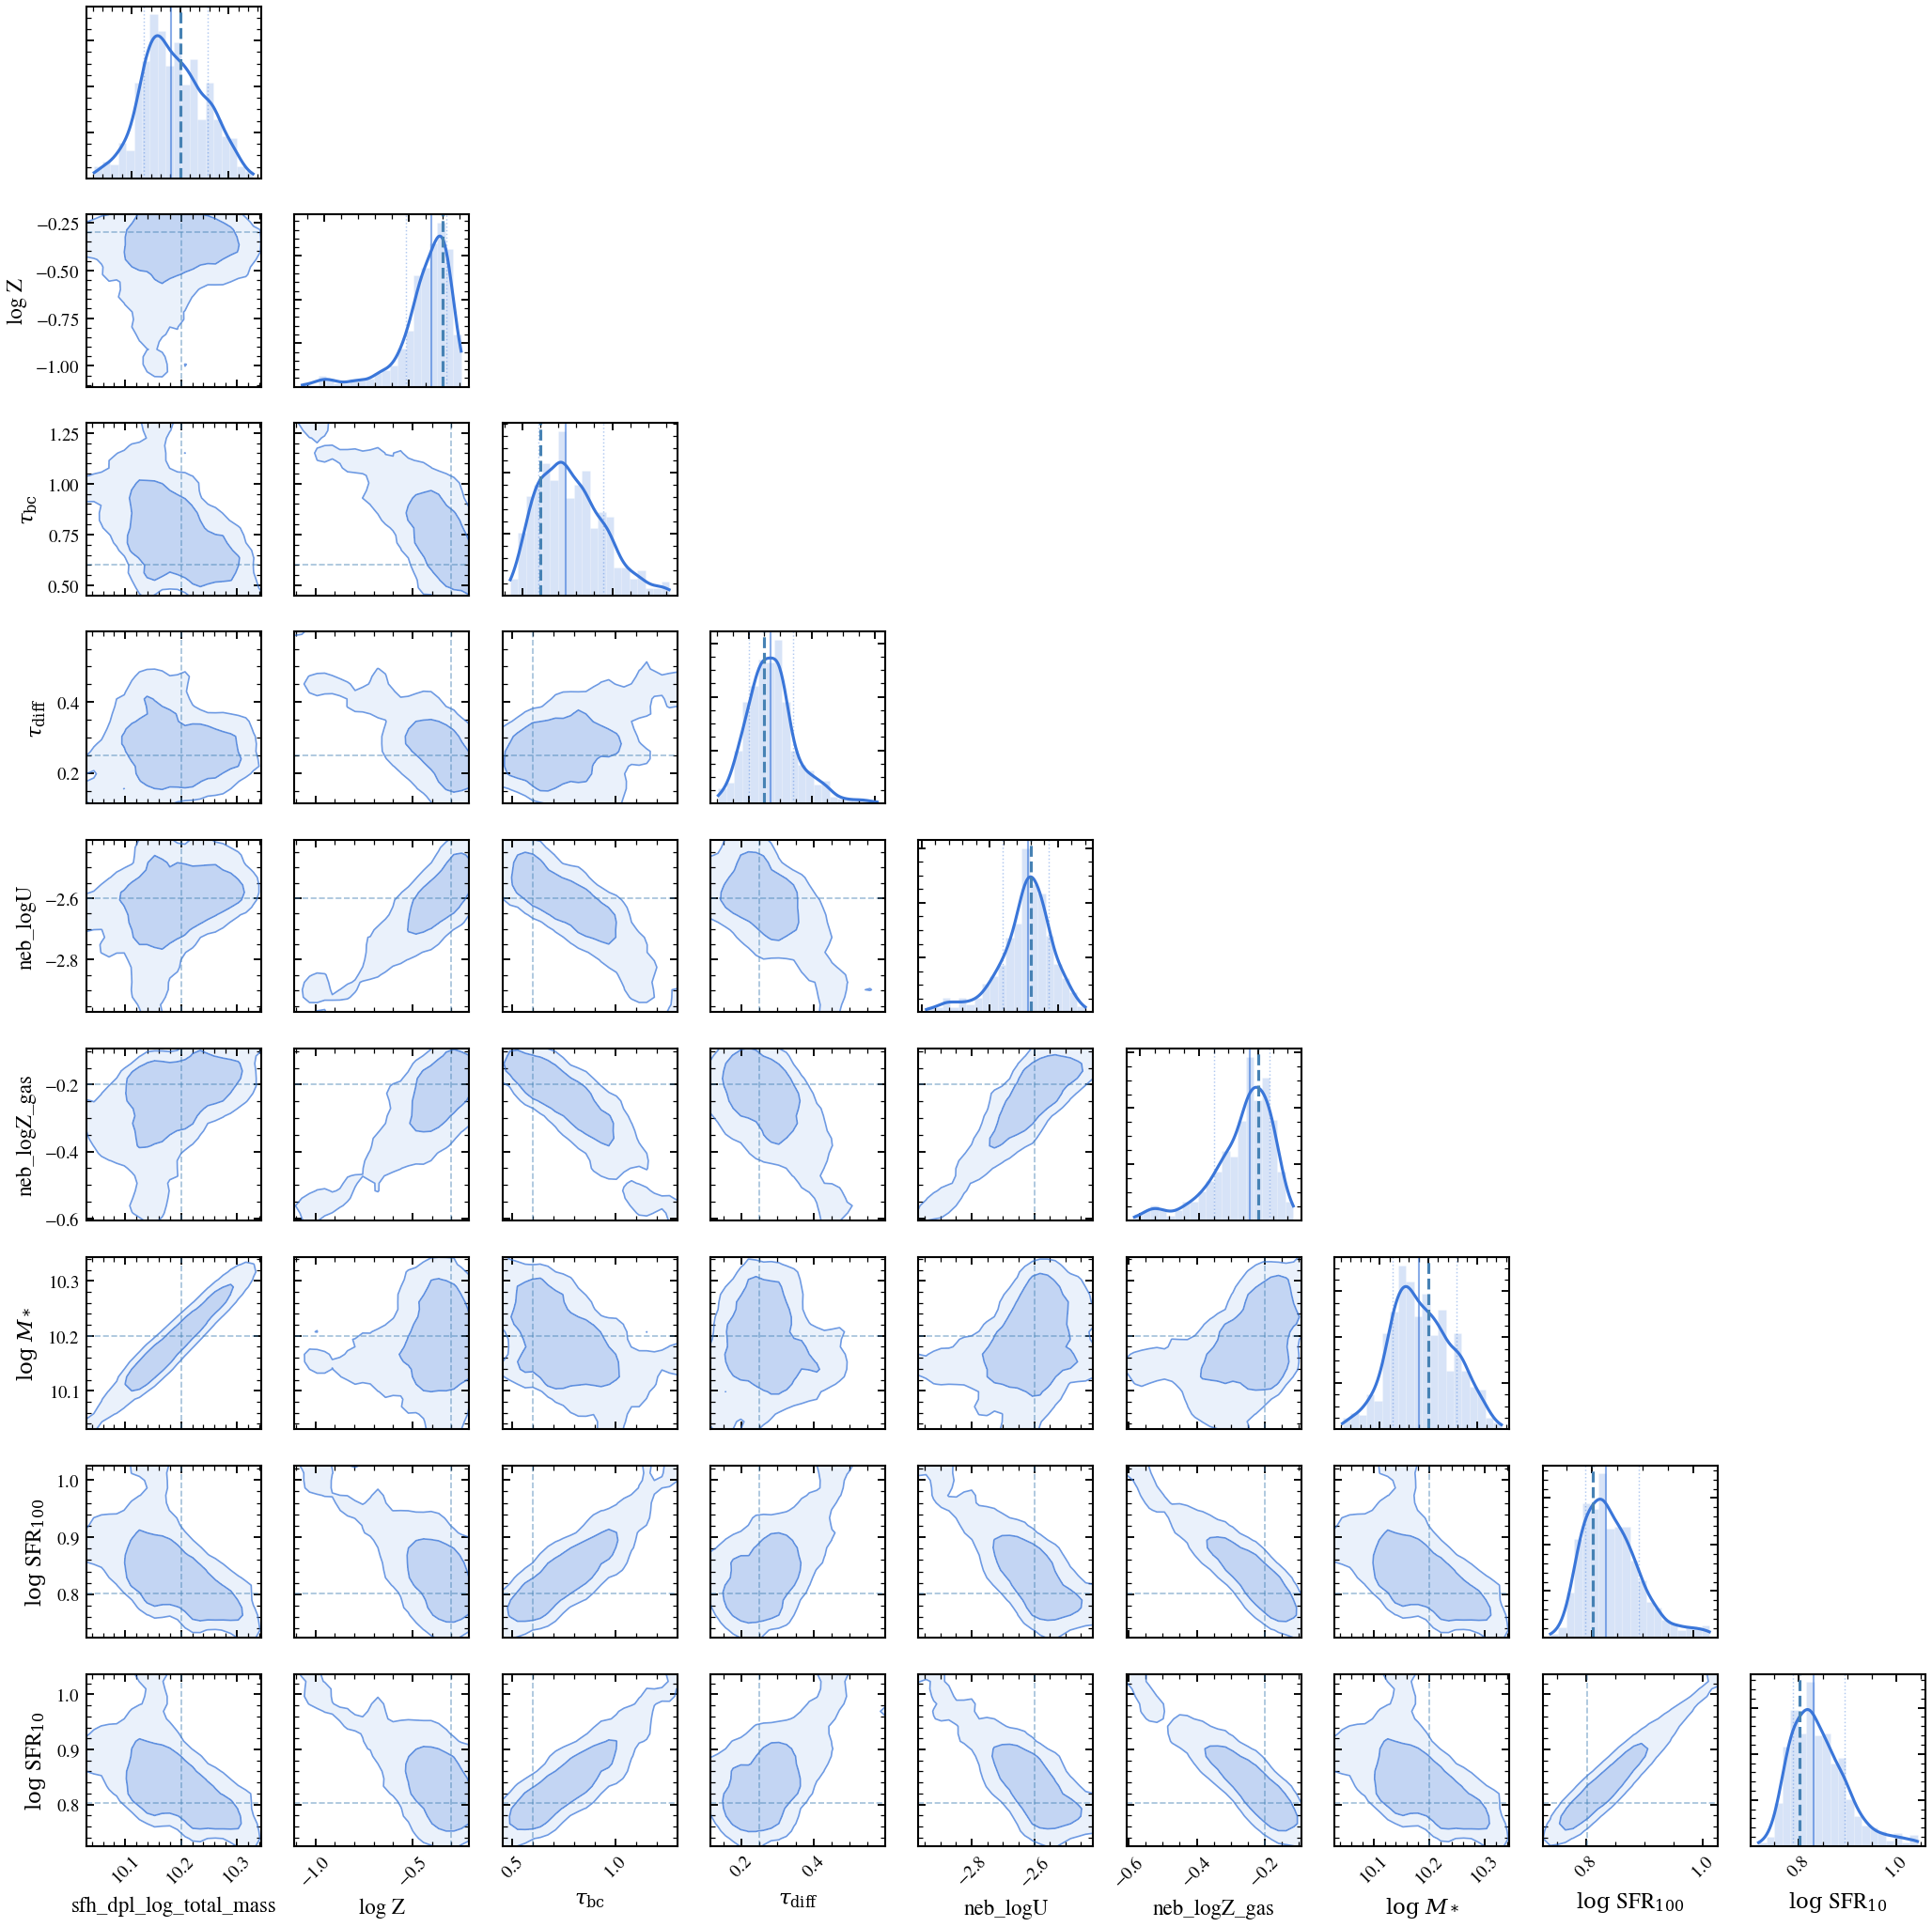

In [8]:
fig_corner = posterior.plot_corner(
    params=REPORT, truths={k: float(v) for k, v in truth_full.items()}, color=C_POST
)
fig_corner.savefig(FIG_DIR / "10_corner.png", dpi=150, bbox_inches="tight")
plt.show()

## Posterior draws for the figures

Evaluated once and reused by both figures below: the model photometry
(`predict_photometry`), the full model SED (`predict(...).rest_sed()` → observed
`F_ν`), and the model line fluxes (`predict_line_fluxes`) — each drawn over the
posterior so the bands carry the parameter uncertainty.

In [9]:
N_DRAW = 80
_sidx = np.linspace(0, len(next(iter(posterior.samples.values()))) - 1, N_DRAW).astype(int)
_fixed = model_fast.spec.get_fixed_values()
draws = [{**_fixed, **{k: jnp.asarray(v[i]) for k, v in posterior.samples.items()}} for i in _sidx]

# Effective wavelength of each band (transmission-weighted), for placing the points.
wave_eff_um = effective_wavelengths_um(phot_obs)

# Model photometry per draw (the band-integrated F_nu the fit is matching).
phot_draws = np.stack([np.asarray(model_fast.predict_photometry(d)) for d in draws])
phot_lo, phot_med, phot_hi = np.percentile(phot_draws, [16, 50, 84], axis=0)

# Continuous model SED per draw: rest-frame L_nu -> observed F_nu (same recipe as
# notebook 07). Observed-frame grid spanning the DECam-to-WISE range.
DL = cosmology.luminosity_distance(Z_GAL)
WAVE_FULL = np.geomspace(2.0e3, 3.0e5, 800)  # observed frame [Å]  (0.2–30 µm)
w_full_um = WAVE_FULL / 1e4


def _sed_fnu(p):
    lnu = np.interp(
        WAVE_FULL / (1.0 + Z_GAL),
        np.asarray(model_fast.wavelengths),
        np.asarray(model_fast.predict(p).rest_sed()),
    )
    return np.asarray(lnu_to_fnu(jnp.asarray(lnu), DL, Z_GAL))


sed_lo, sed_med, sed_hi = np.percentile(
    np.stack([_sed_fnu(p) for p in draws]), [16, 50, 84], axis=0
)
sed_truth = _sed_fnu(truth_full)

## Do the points match the best fit? — photometry

The observed photometry on the best-fit SED, with the per-band residual below.
The lower panel is the pull, `(observed − model) / σ`: inside ±1 (gray band)
means the model reproduces that band within its error bar. The reduced χ² over
the 7 bands quantifies the overall photometric match.

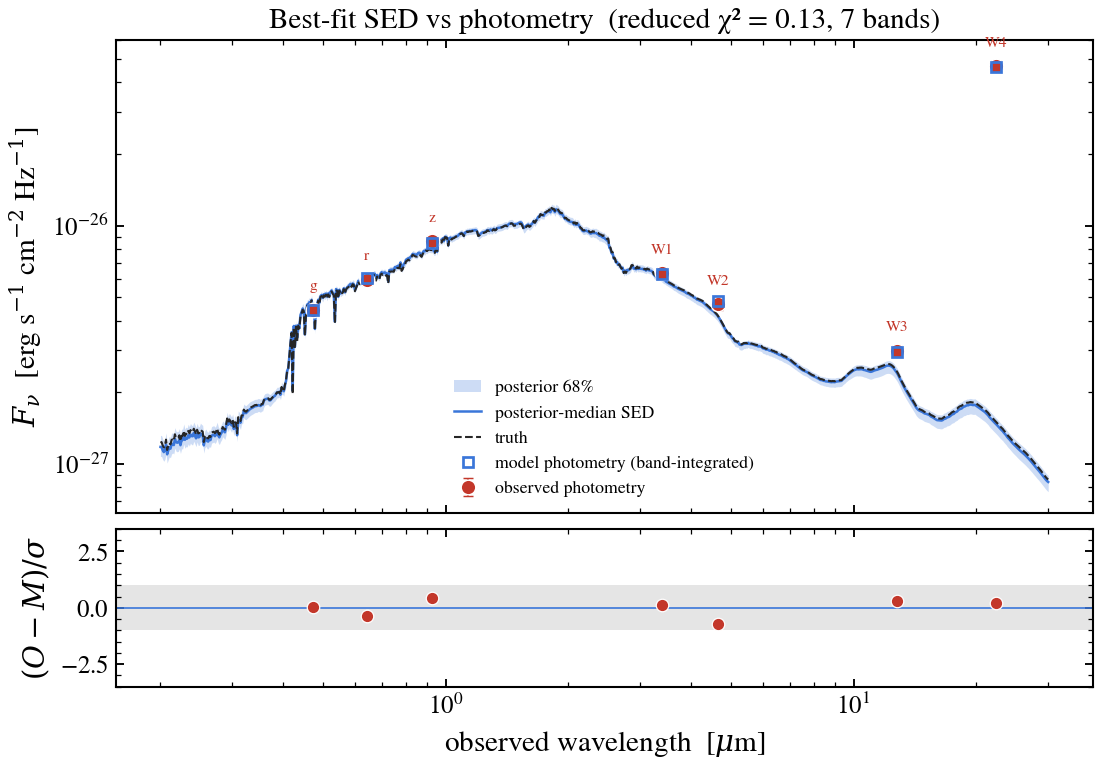

In [10]:
BAND_LABELS = ["g", "r", "z", "W1", "W2", "W3", "W4"]
pull_phot = (flux_phot - phot_med) / n_phot
chi2_phot = float(np.sum(pull_phot**2))

fig, (axs, axr) = plt.subplots(
    2, 1, figsize=(8.4, 5.6), sharex=True, gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)
axs.fill_between(w_full_um, sed_lo, sed_hi, color=C_POST, alpha=0.25, lw=0, label="posterior 68%")
axs.plot(w_full_um, sed_med, color=C_POST, lw=1.2, label="posterior-median SED")
axs.plot(w_full_um, sed_truth, color=C_TRUTH, lw=1.0, ls="--", label="truth")
axs.errorbar(
    wave_eff_um,
    flux_phot,
    yerr=n_phot,
    fmt="o",
    ms=7,
    color=C_DATA,
    mec="white",
    mew=0.7,
    elinewidth=1.1,
    capsize=2.5,
    zorder=6,
    label="observed photometry",
)
axs.plot(
    wave_eff_um,
    phot_med,
    marker="s",
    ms=5,
    ls="none",
    mfc="none",
    mec=C_POST,
    mew=1.3,
    zorder=7,
    label="model photometry (band-integrated)",
)
for name, x, y, e in zip(BAND_LABELS, wave_eff_um, flux_phot, n_phot):
    axs.annotate(
        name,
        (x, y + e),
        textcoords="offset points",
        xytext=(0, 7),
        ha="center",
        fontsize=7.5,
        color=C_DATA,
    )
axs.set_xscale("log")
axs.set_yscale("log")
axs.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
axs.set_title(
    f"Best-fit SED vs photometry  (reduced χ² = {chi2_phot / len(flux_phot):.2f}, 7 bands)"
)
axs.legend(frameon=False, fontsize=8.5, loc="lower center")

axr.axhspan(-1, 1, color="0.6", alpha=0.25, lw=0)
axr.axhline(0, color=C_POST, lw=0.8)
axr.plot(wave_eff_um, pull_phot, "o", ms=6, color=C_DATA, mec="white", mew=0.6)
axr.set_xscale("log")
axr.set_ylim(-3.5, 3.5)
axr.set_xlabel(r"observed wavelength  [$\mu$m]")
axr.set_ylabel(r"$(O-M)/\sigma$")
fig.savefig(FIG_DIR / "10_sed_photometry.png", dpi=300, bbox_inches="tight")
plt.show()

## Do the points match the best fit? — emission lines

The same test for the line channel: observed line fluxes (points) against the
posterior-predictive `predict_line_fluxes` (band + median), with the per-line
pull below. Lines are categorical, so they are *not* joined by a curve — each is
an independent measurement. The reduced χ² is over the ten lines.

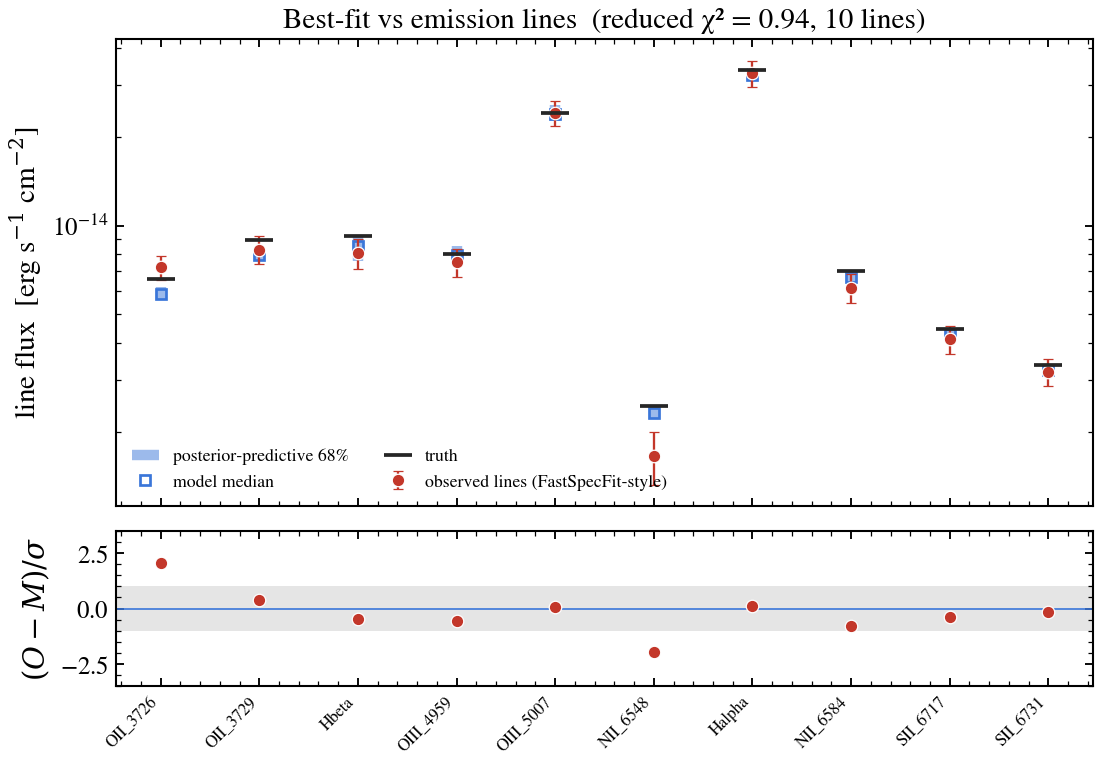

In [11]:
line_draws = np.stack(
    [np.asarray(model_fast.predict_line_fluxes(d, target_wavelengths=LINE_WAVES)) for d in draws]
)
line_lo, line_med, line_hi = np.percentile(line_draws, [16, 50, 84], axis=0)
pull_line = (flux_line - line_med) / n_line
chi2_line = float(np.sum(pull_line**2))
x = np.arange(len(LINE_NAMES))

fig, (axl, axp) = plt.subplots(
    2, 1, figsize=(8.4, 5.6), sharex=True, gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08}
)
axl.errorbar(
    x,
    flux_line,
    yerr=n_line,
    fmt="o",
    color=C_DATA,
    ms=6,
    mec="white",
    mew=0.6,
    elinewidth=1.1,
    capsize=2.5,
    zorder=4,
    label="observed lines (FastSpecFit-style)",
)
axl.vlines(
    x, line_lo, line_hi, color=C_POST, alpha=0.5, lw=5, zorder=2, label="posterior-predictive 68%"
)
axl.plot(
    x,
    line_med,
    marker="s",
    ms=5,
    ls="none",
    mfc="none",
    mec=C_POST,
    mew=1.3,
    zorder=3,
    label="model median",
)
axl.plot(x, p_line, marker="_", ms=13, mew=1.8, ls="none", color=C_TRUTH, zorder=5, label="truth")
axl.set_yscale("log")
axl.set_ylabel(r"line flux  [erg s$^{-1}$ cm$^{-2}$]")
axl.set_title(
    f"Best-fit vs emission lines  (reduced χ² = {chi2_line / len(LINE_NAMES):.2f}, 10 lines)"
)
axl.legend(fontsize=8.5, loc="lower left", ncol=2)

axp.axhspan(-1, 1, color="0.6", alpha=0.25, lw=0)
axp.axhline(0, color=C_POST, lw=0.8)
axp.plot(x, pull_line, "o", ms=6, color=C_DATA, mec="white", mew=0.6)
axp.set_ylim(-3.5, 3.5)
axp.set_ylabel(r"$(O-M)/\sigma$")
axp.set_xticks(x)
axp.set_xticklabels(LINE_NAMES, rotation=45, ha="right", fontsize=8)
fig.savefig(FIG_DIR / "10_line_recovery.png", dpi=300, bbox_inches="tight")
plt.show()

## Measured times, together

Two columns, because they answer different questions. **`fit() wall`** is the
single-galaxy interactive cost, which carries the per-call JIT compile.
**`compiled step`** is the optimization once compiled: the marginal per-galaxy
compute a catalog pays after amortizing the compile (via `fit_batch`), and the
only place an `approx=` choice can show up. Three rows, so the middle one
separates the two opt-ins instead of bundling them.

On this fit the three rows are the same to within noise. That is the result,
not a failed measurement — see the note under the timing cell above.

In [12]:
print(f"{'fit':<34}{'fit() wall':>13}{'compiled step':>15}")
print("-" * 62)
print(f"{'MAP, exact wave grid':<34}{warm_e:>10.2f} s{loop_e:>12.2f} s")
print(f"{'MAP, WavePrecomp only':<34}{warm_w:>10.2f} s{loop_w:>12.2f} s")
print(f"{'MAP, WavePrecomp+FeaturePrecomp':<34}{warm_f:>10.2f} s{loop_f:>12.2f} s")
print(
    f"\nCompiled-step ratio: {loop_e / loop_f:.1f}x overall — {loop_e / loop_w:.1f}x from WavePrecomp,"
)
print(
    f"a further {loop_w / loop_f:.1f}x from FeaturePrecomp. The fit() wall (~{warm_f:.1f}s) is per-call JIT"
)
print("compile, not the fit — a catalog amortizes it once with fit_batch and pays only the")
print("compiled step per galaxy. The FeaturePrecomp nebular grid is likewise a one-time build")
print(
    f"({model_fast.spec.n_free}-parameter model), reused across every fit that shares the model."
)

fit                                  fit() wall  compiled step
--------------------------------------------------------------
MAP, exact wave grid                    0.33 s        0.15 s
MAP, WavePrecomp only                   0.41 s        0.19 s
MAP, WavePrecomp+FeaturePrecomp         0.36 s        0.15 s

Compiled-step ratio: 1.0x overall — 0.8x from WavePrecomp,
a further 1.3x from FeaturePrecomp. The fit() wall (~0.4s) is per-call JIT
compile, not the fit — a catalog amortizes it once with fit_batch and pays only the
compiled step per galaxy. The FeaturePrecomp nebular grid is likewise a one-time build
(10-parameter model), reused across every fit that shares the model.


## Summary

- A **FastSpecFit-style catalog** — broadband photometry + emission-line
  fluxes — is fit through one `Observation` carrying both, with the lines in a
  `LineFluxData`. No extra wiring: the fit picks up the line likelihood.
- Model a catalog line flux with **`predict_line_fluxes`** — pure, deblended,
  absorption-corrected emission, the same quantity FastSpecFit's `LINE_FLUX`
  reports (Gaussian on a continuum-subtracted spectrum). A window-integrated
  `measure_line_fluxes` is a *different* quantity (it carries stellar
  absorption and mis-deblends [N II]) and should not be compared to a catalog.
- The **`(WavePrecomp, FeaturePrecomp)`** fast path turns each likelihood
  evaluation into a table look-up, reproducing the exact forward to sub-percent
  on the strong lines. Its win at catalog scale is real and separate: batched
  over galaxies with `fit_batch`, the look-up is built once and shared.
- **On this particular fit it buys almost nothing, and the timing above says
  so.** Do not assume an `approx=` choice is helping — measure it. An
  observation carrying a line channel already keeps the nebular work off the
  per-gradient path, so the exact forward starts out fast and the lookups have
  little left to remove.
- The two opt-ins are **not one per data channel**. `FeaturePrecomp` caches the
  *nebular* calculation, not the line channel: with `neb_logU` and
  `neb_logZ_gas` free, a likelihood evaluation without it can re-run the Cue
  emulator. That is why the case it rescues is the counter-intuitive one — the
  same model fit to **photometry alone**, where it is worth roughly an order of
  magnitude. "I am not fitting lines" is not a reason to leave it off.
- **The truth lands inside the 68% interval for the reported parameters** —
  the coverage line printed above is the measurement, and on six parameters at
  68% nominal coverage both five and six are what a calibrated interval should
  give, so do not read a single miss as a failure (or a clean sweep as proof).
  Stellar mass and SFR are the tightest. Metallicity / dust / gas conditions
  are the broad, degenerate sector — the posterior *width* is the honest
  statement of that. More information (a full spectrum — notebook 06 — an
  auroral line, or the UV slope) narrows it, not a faster fit.
- Two residual systematics matter when fitting a *real* catalog: the nebular
  model floor (Cue reproduces FSPS's Cloudy to ~10%, ~30% for [S II]), and the
  fiber aperture (line fluxes are aperture-limited; photometry is total — apply
  the catalog's aperture correction or fiber-match).